In [1]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages


class state(TypedDict):
   # Message have the type "list". The `add_messages` function will convert it to a list of messages.
   # in the Annotated type, we specify that the value of "message" is a list of strings.
   # (in this case, it append message to the list, eather than overwriting them)
   messages: Annotated[list,add_messages]
                       


In [2]:
graph_builder = StateGraph(state)
graph_builder

In [3]:
import os
from dotenv import load_dotenv
load_dotenv()


True

In [4]:
from langchain_groq import ChatGroq
from langchain.chat_models import init_chat_model

llm = ChatGroq(
    model="llama-3.1-8b-instant",
)
llm

ChatGroq(output_version=None, profile={'max_input_tokens': 8192, 'max_output_tokens': 8192, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x1116b78d0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x11177bd50>, model_name='llama3-8b-8192', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [9]:
llm = init_chat_model("groq:llama-3.1-8b-instant")
llm

ChatGroq(output_version=None, profile={'max_input_tokens': 131072, 'max_output_tokens': 8192, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x113009690>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x112d90090>, model_name='llama-3.1-8b-instant', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [10]:
from typing import Any, Dict
State = Dict[str, Any]

def chatbot(state: State):
    return {"messages": [llm.invoke(state["messages"])]}

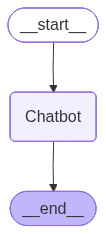

In [7]:
graph_builder = StateGraph(state)
# ADD NODES 
graph_builder.add_node("Chatbot", chatbot)
# ADD EDGES
graph_builder.add_edge(START, "Chatbot")
# ADD EDGE TO END NODE
graph_builder.add_edge("Chatbot", END)

# COMPILE THE GRAPH
graph = graph_builder.compile()

graph


In [14]:
res = graph.invoke({
    "messages": [("user", "What is the capital of France?")],
})

res["messages"][-1].content

'The capital of France is Paris.'

In [18]:
for event in graph.stream({
    "messages": [("user", "What is the capital of France?")]
}):
    for value in event.values():
        print(value["messages"][-1].content)    

The capital of France is Paris.
